# Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

save_path = '../kg/'

In [2]:
nodes = pd.read_csv(save_path+"nodes.csv", low_memory=False)
print("实体总数量:", nodes.shape[0])
print("不同类型实体数量:", nodes['node_type'].value_counts())

实体总数量: 121649
不同类型实体数量: node_type
disease               28063
biological_process    26037
gene/protein          22339
effect/phenotype      18607
molecular_function    10154
drug                   9542
cellular_component     4023
pathway                2884
Name: count, dtype: int64


In [3]:
edges = pd.read_csv(save_path+"kg.csv", low_memory=False)
edges.head()

,relation,display_relation,x_index,x_id,x_type,x_name,x_source,y_index,y_id,y_type,y_name,y_source
0,protein_protein,ppi,0,kg4rd:381,gene/protein,ARF5,NCBI,1898,kg4rd:4907,gene/protein,NT5E,NCBI
1,protein_protein,ppi,0,kg4rd:381,gene/protein,ARF5,NCBI,769,kg4rd:1845,gene/protein,DUSP3,NCBI
2,protein_protein,ppi,0,kg4rd:381,gene/protein,ARF5,NCBI,15031,kg4rd:84364,gene/protein,ARFGAP2,NCBI
3,protein_protein,ppi,0,kg4rd:381,gene/protein,ARF5,NCBI,2385,kg4rd:23071,gene/protein,ERP44,NCBI
4,protein_protein,ppi,0,kg4rd:381,gene/protein,ARF5,NCBI,4981,kg4rd:10972,gene/protein,TMED10,NCBI


In [4]:
total_relations = edges.shape[0]
print("关系总数量:", total_relations)
relation_counts = edges['relation'].value_counts()
relation_percent = (relation_counts / total_relations * 100).round(3)
relation_summary = pd.DataFrame({
    '关系数量': relation_counts,
    '占比(%)': relation_percent
})
print("不同类型关系数量及占比:")
print(relation_summary)

关系总数量: 4617425
不同类型关系数量及占比:
                               关系数量   占比(%)
relation                                   
drug_drug                   2855310  61.838
protein_protein              715533  15.496
disease_phenotype_positive   224016   4.852
bioprocess_protein           157420   3.409
cellcomp_protein             106485   2.306
molfunc_protein               92348   2.000
phenotype_protein             72403   1.568
disease_protein               68743   1.489
disease_disease               67038   1.452
drug_effect                   60662   1.314
pathway_protein               45665   0.989
bioprocess_bioprocess         45416   0.984
drug_protein                  31476   0.682
phenotype_phenotype           22097   0.479
contraindication              20255   0.439
molfunc_molfunc               12572   0.272
indication                     6881   0.149
cellcomp_cellcomp              4615   0.100
drug_pathway                   3252   0.070
pathway_pathway                2893   0.063
off-

In [8]:
def degree_distribution(type_: str, threshold: int = 500):
    plt.rcParams['figure.dpi'] = 150  # 提高图片分辨率
    plt.rcParams['font.family'] = 'serif'  # 设置字体

    all_type_nodes = nodes.query(f'node_type == "{type_}"')[['node_index']].astype({'node_index': int}).astype({'node_index': str})

    out_degree = edges.query(f'x_type == "{type_}"').groupby('x_index').count()['relation'].reset_index().astype({'x_index': int}).astype({'x_index': str})
    out_degree = pd.merge(out_degree, all_type_nodes, left_on='x_index', right_on='node_index', how='right')
    out_degree = out_degree[['relation', 'node_index']].fillna(0).astype({'relation': int})
    out_degree = out_degree['relation']
    
    in_degree = edges.query(f'y_type == "{type_}"').groupby('y_index').count()['relation'].reset_index().astype({'y_index': int}).astype({'y_index': str})
    in_degree = pd.merge(in_degree, all_type_nodes, left_on='y_index', right_on='node_index', how='right')
    in_degree = in_degree[['relation', 'node_index']].fillna(0).astype({'relation': int})
    in_degree = in_degree['relation']

    out_threshold = out_degree <= threshold
    in_threshold = in_degree <= threshold

    filtered_out = out_degree[out_threshold]
    filtered_in = in_degree[in_threshold]

    out_filtered_count = (~out_threshold).sum()  # 被过滤的节点数量
    in_filtered_count = (~in_threshold).sum()
    out_filtered_percent = (out_filtered_count / len(out_degree)) * 100
    in_filtered_percent = (in_filtered_count / len(in_degree)) * 100

    plt.figure(figsize=(14, 6))

    plt.subplot(121)
    plt.hist(filtered_out, bins=20, alpha=0.7, color='#3498db', edgecolor='#2980b9', linewidth=1)
    plt.grid(True, alpha=0.3)
    plt.title(f'Out-degree Distribution for {type_}', fontsize=10)
    plt.xlabel('Out-degree')
    plt.ylabel('Count')
    plt.figtext(0.45, 0.95, 
        f'Filtered degree > {threshold} ({out_filtered_count} nodes, {out_filtered_percent:.3f}%)\n'
        f'Sum = {out_degree.sum()}\n'
        f'Mean = {out_degree.mean():.3f}', 
        transform=plt.gca().transAxes, 
        bbox=dict(facecolor='white', alpha=0.8),
        verticalalignment='top'
    )

    plt.subplot(122)
    plt.hist(filtered_in, bins=20, alpha=0.7, color='#3498db', edgecolor='#2980b9', linewidth=1)
    plt.grid(True, alpha=0.3)
    plt.title(f'In-degree Distribution for {type_}', fontsize=10)
    plt.xlabel('In-degree')
    plt.ylabel('Count')
    plt.figtext(0.45, 0.95, 
        f'Filtered degree > {threshold} ({in_filtered_count} nodes, {in_filtered_percent:.3f}%)\n'
        f'Sum = {in_degree.sum()}\n'
        f'Mean = {in_degree.mean():.3f}', 
        transform=plt.gca().transAxes, 
        bbox=dict(facecolor='white', alpha=0.8),
        verticalalignment='top'
    )

    plt.tight_layout()
    plt.show()


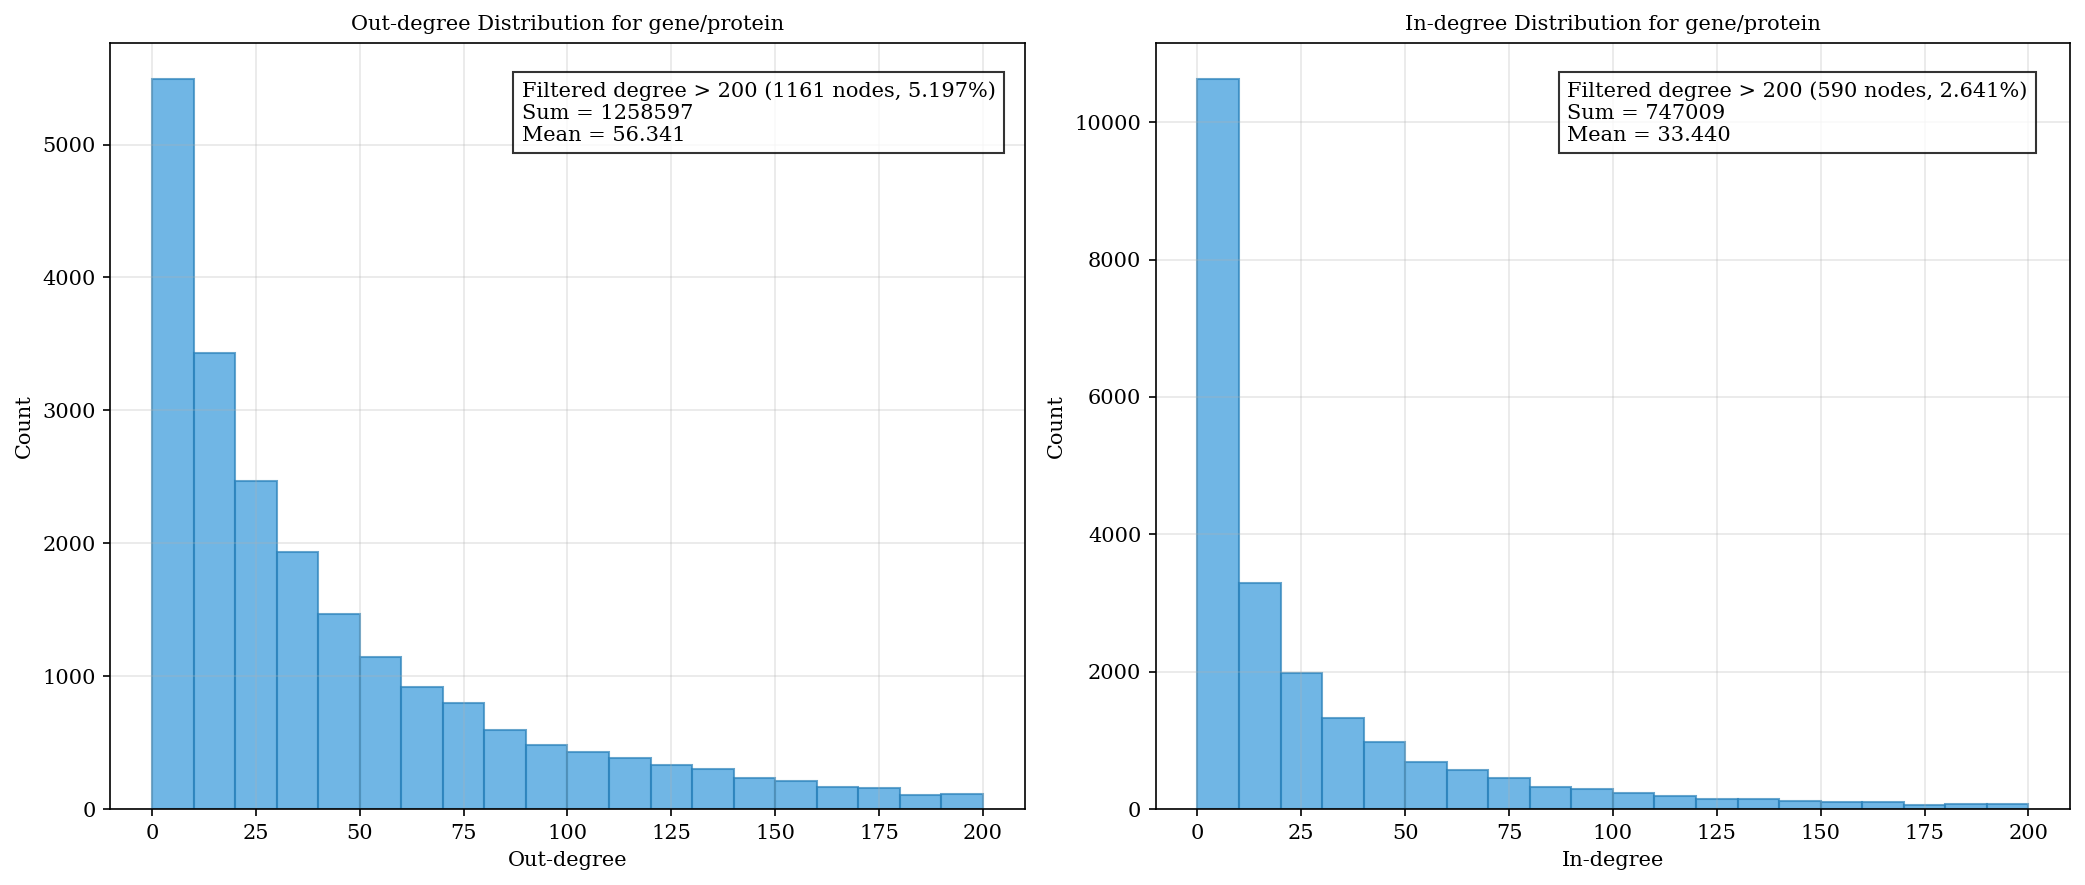

In [9]:
degree_distribution('gene/protein', threshold=200)

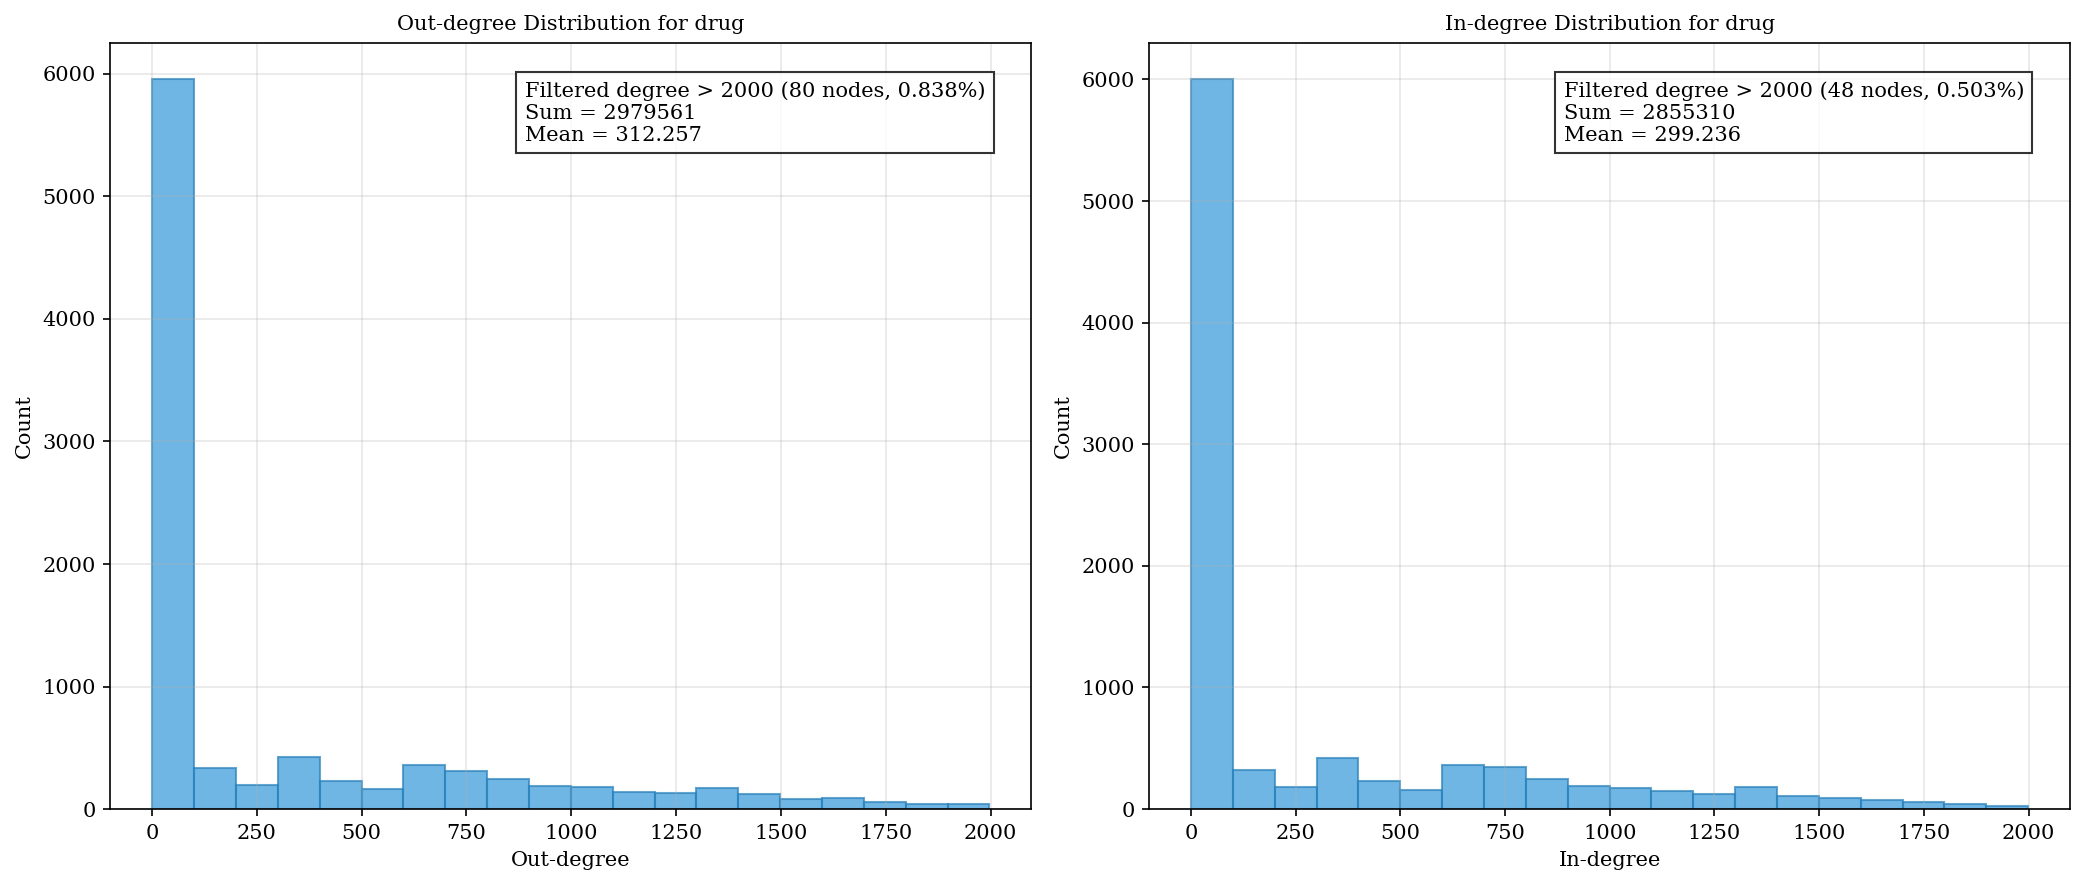

In [10]:
degree_distribution('drug', threshold=2000)

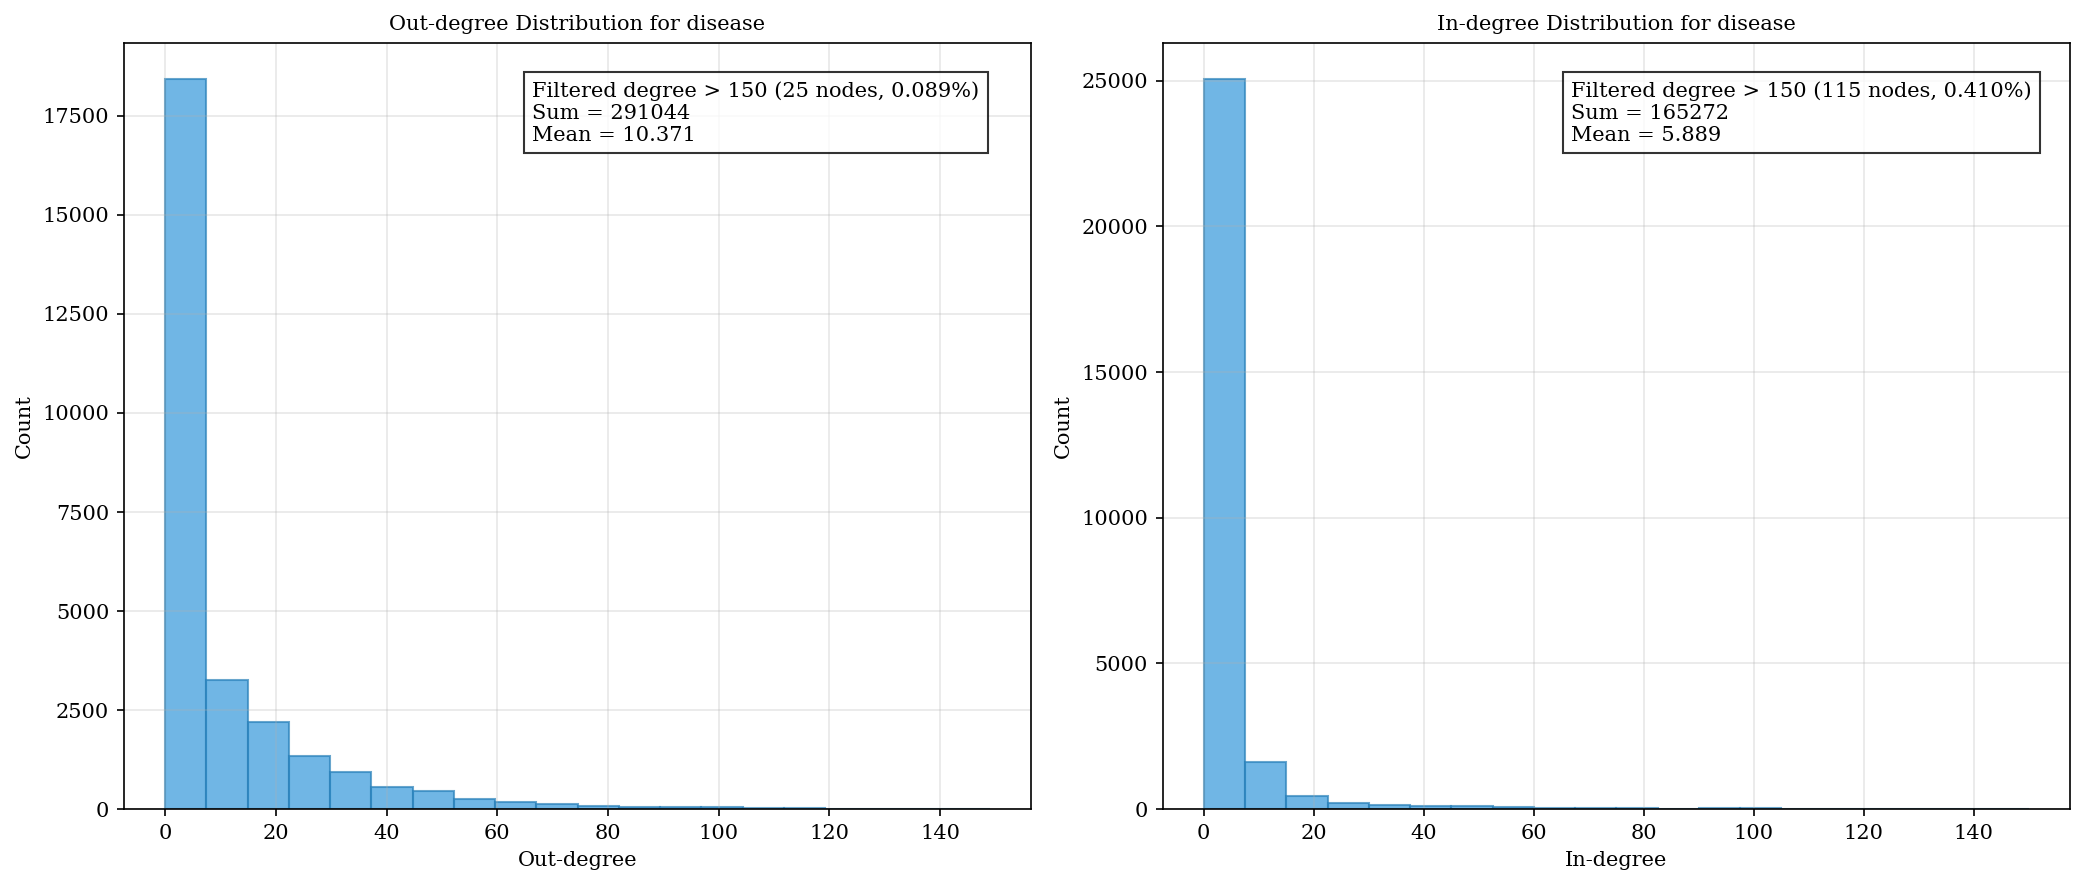

In [11]:
degree_distribution('disease', threshold=150)

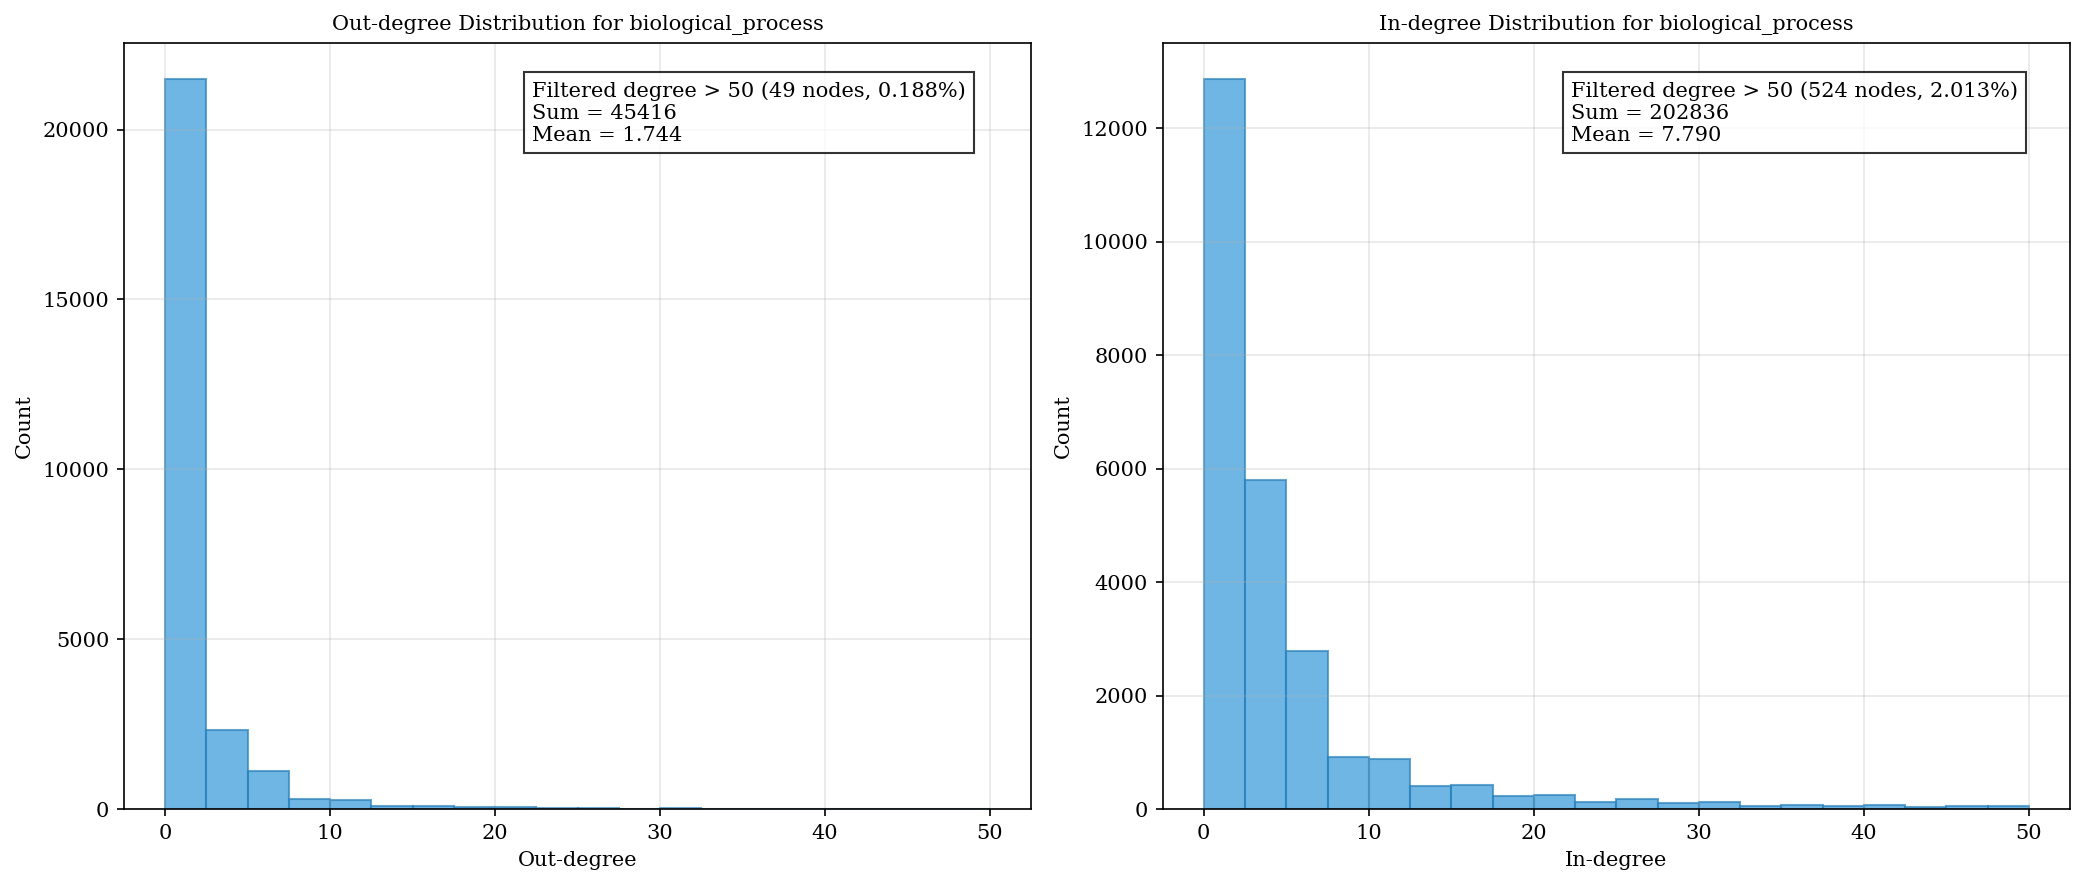

In [12]:
degree_distribution('biological_process', threshold=50)

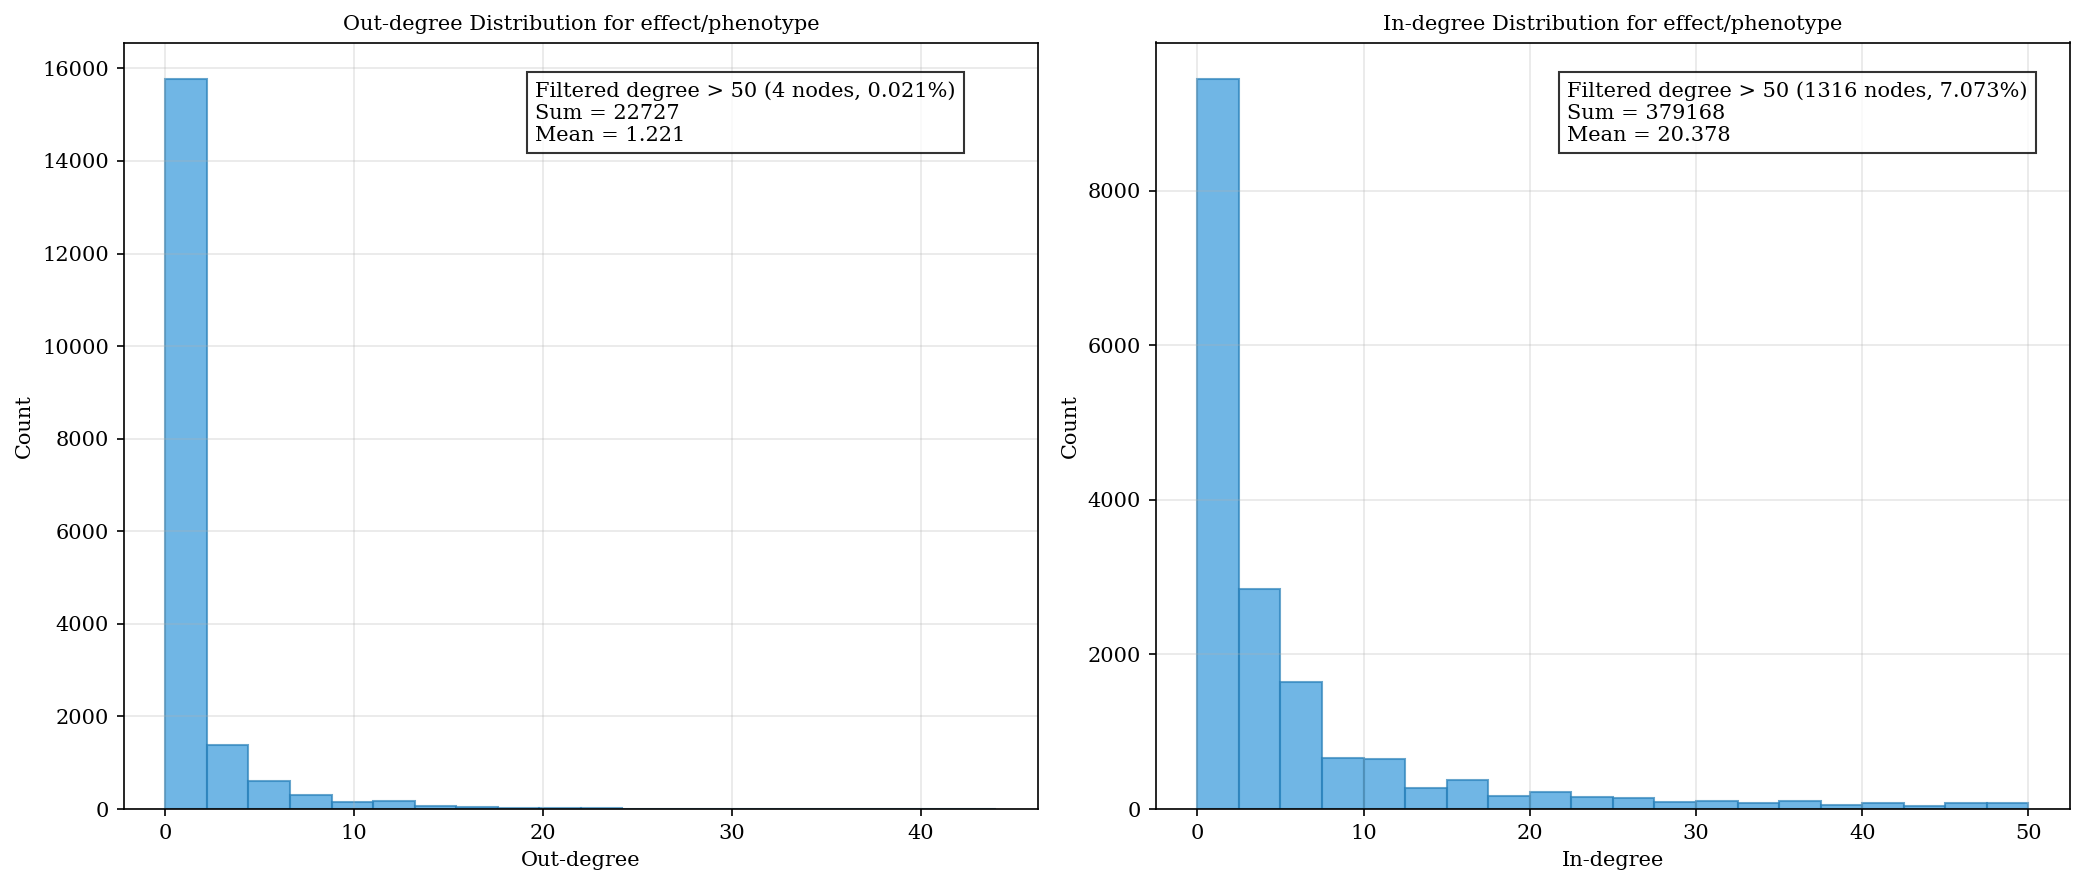

In [13]:
degree_distribution('effect/phenotype', threshold=50)

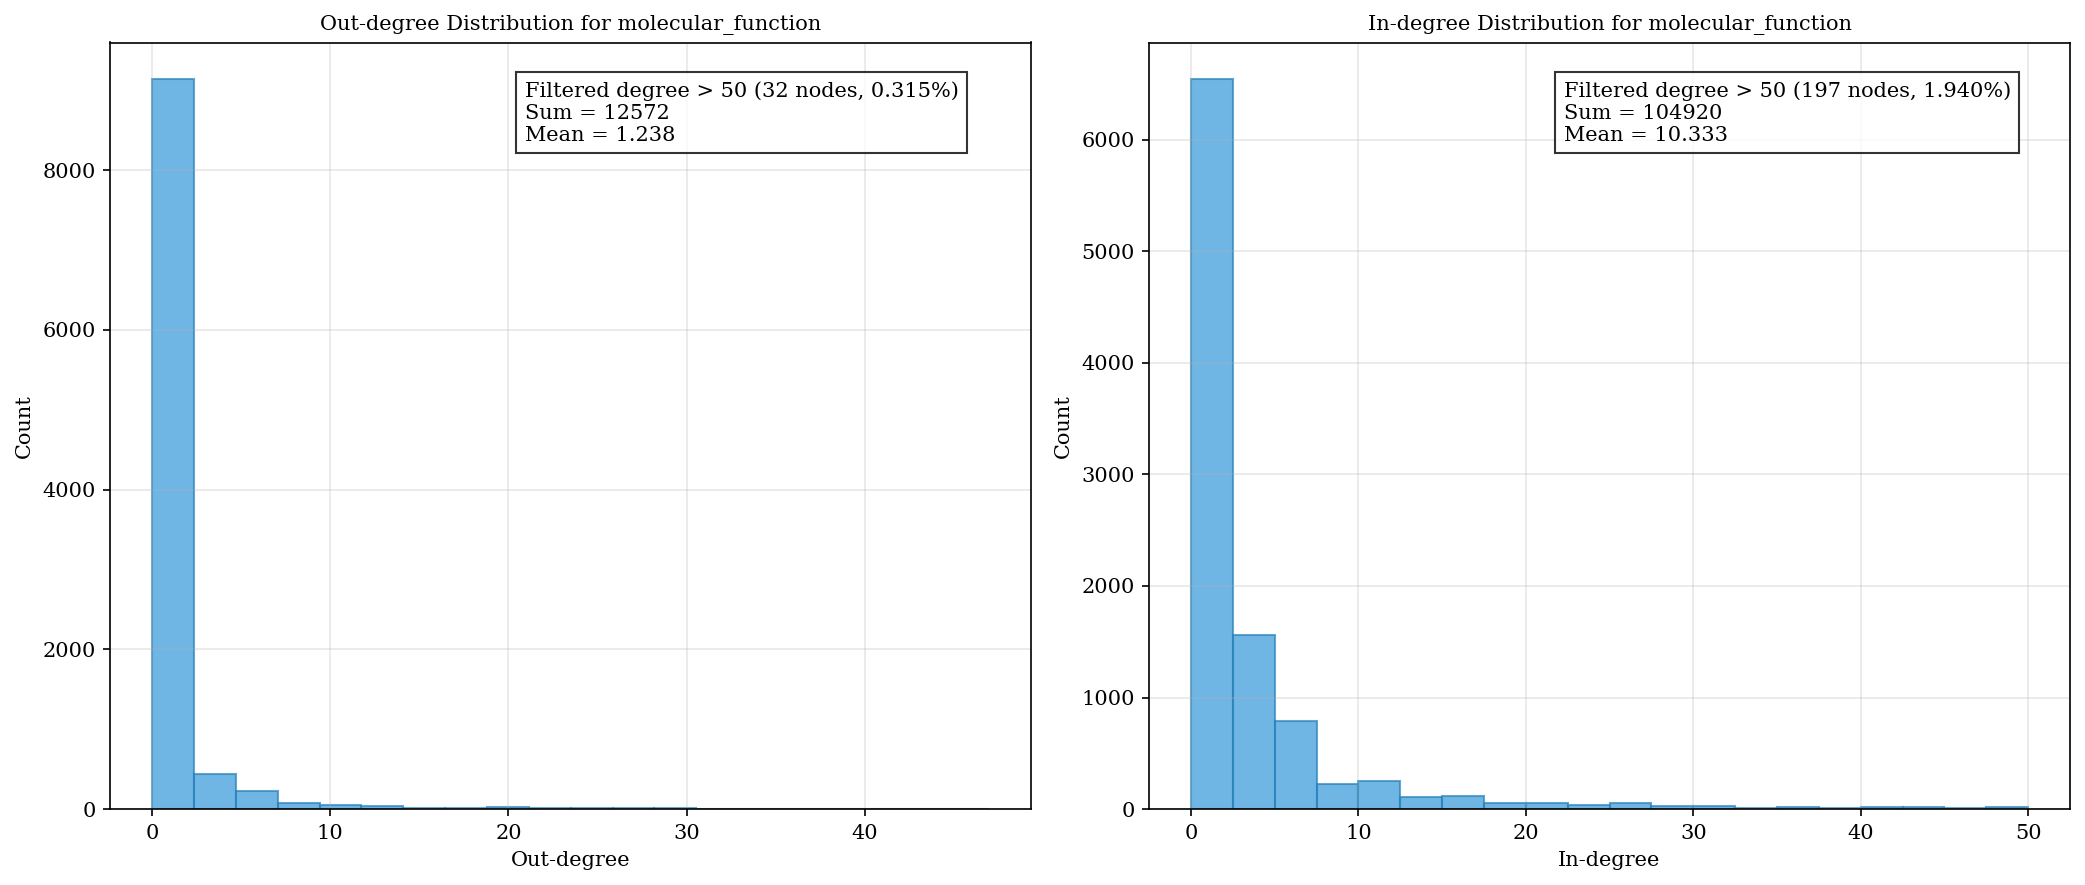

In [14]:
degree_distribution('molecular_function', threshold=50)

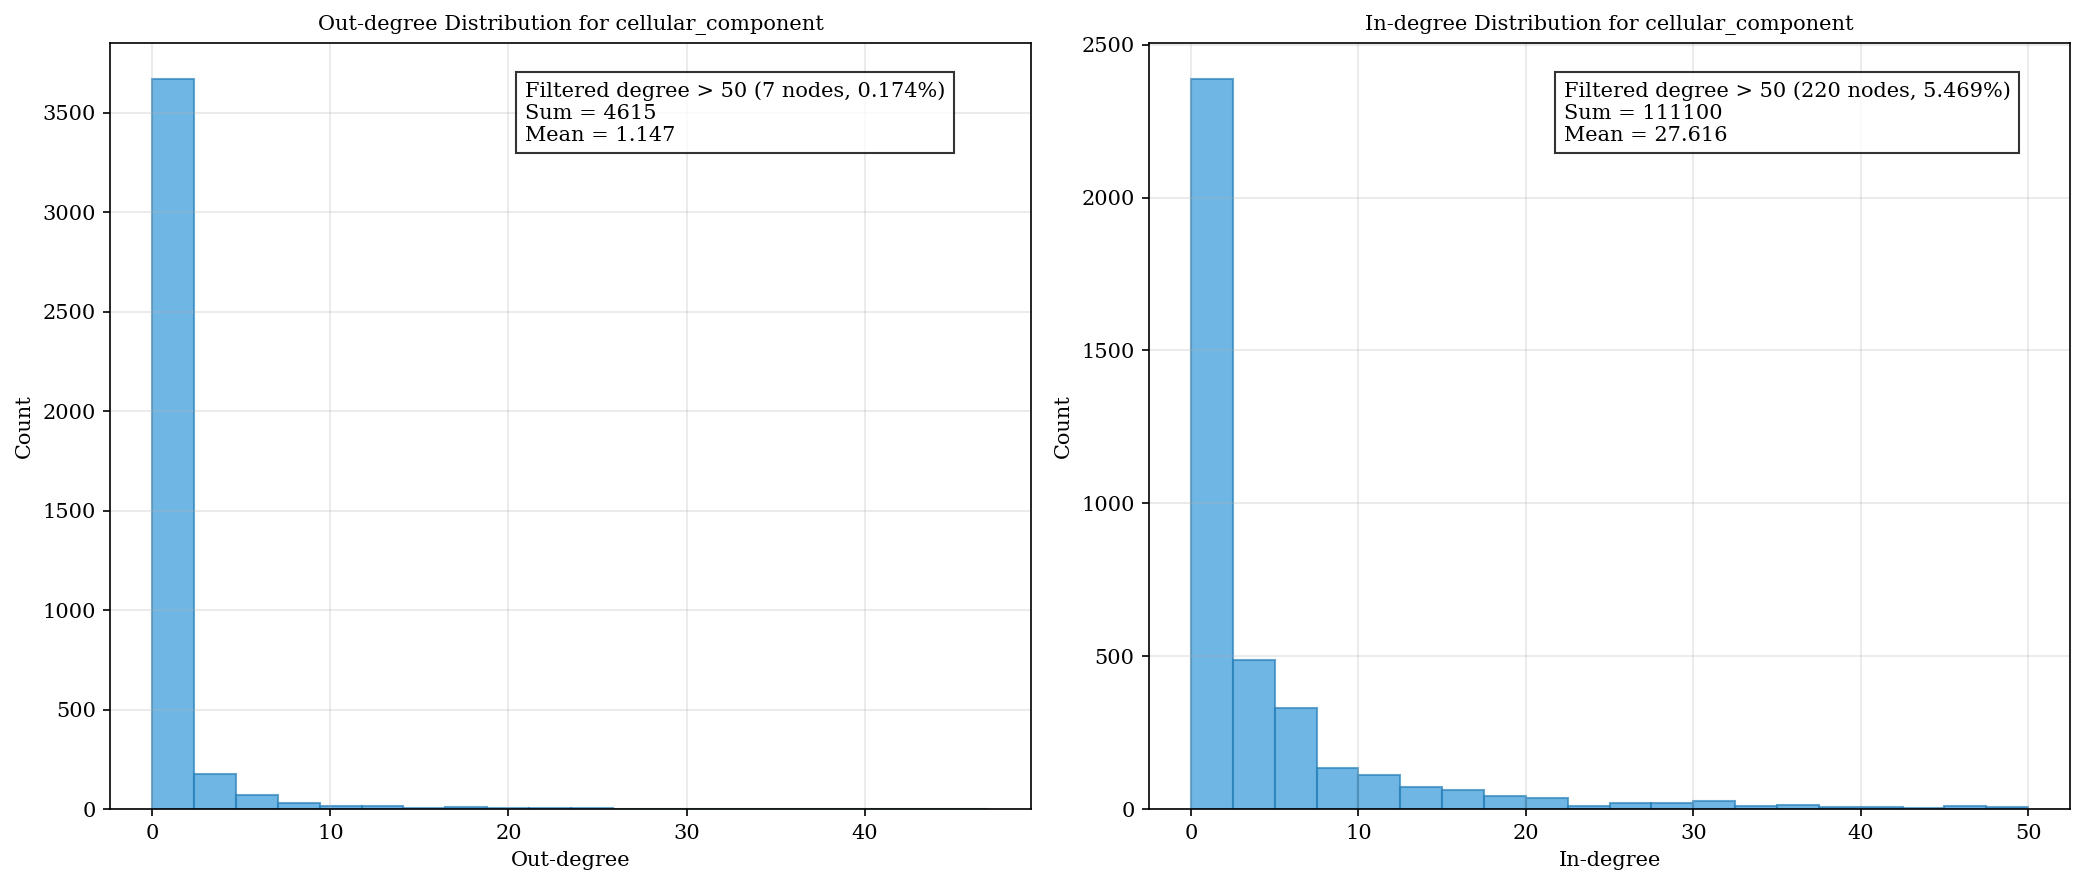

In [15]:
degree_distribution('cellular_component', threshold=50)

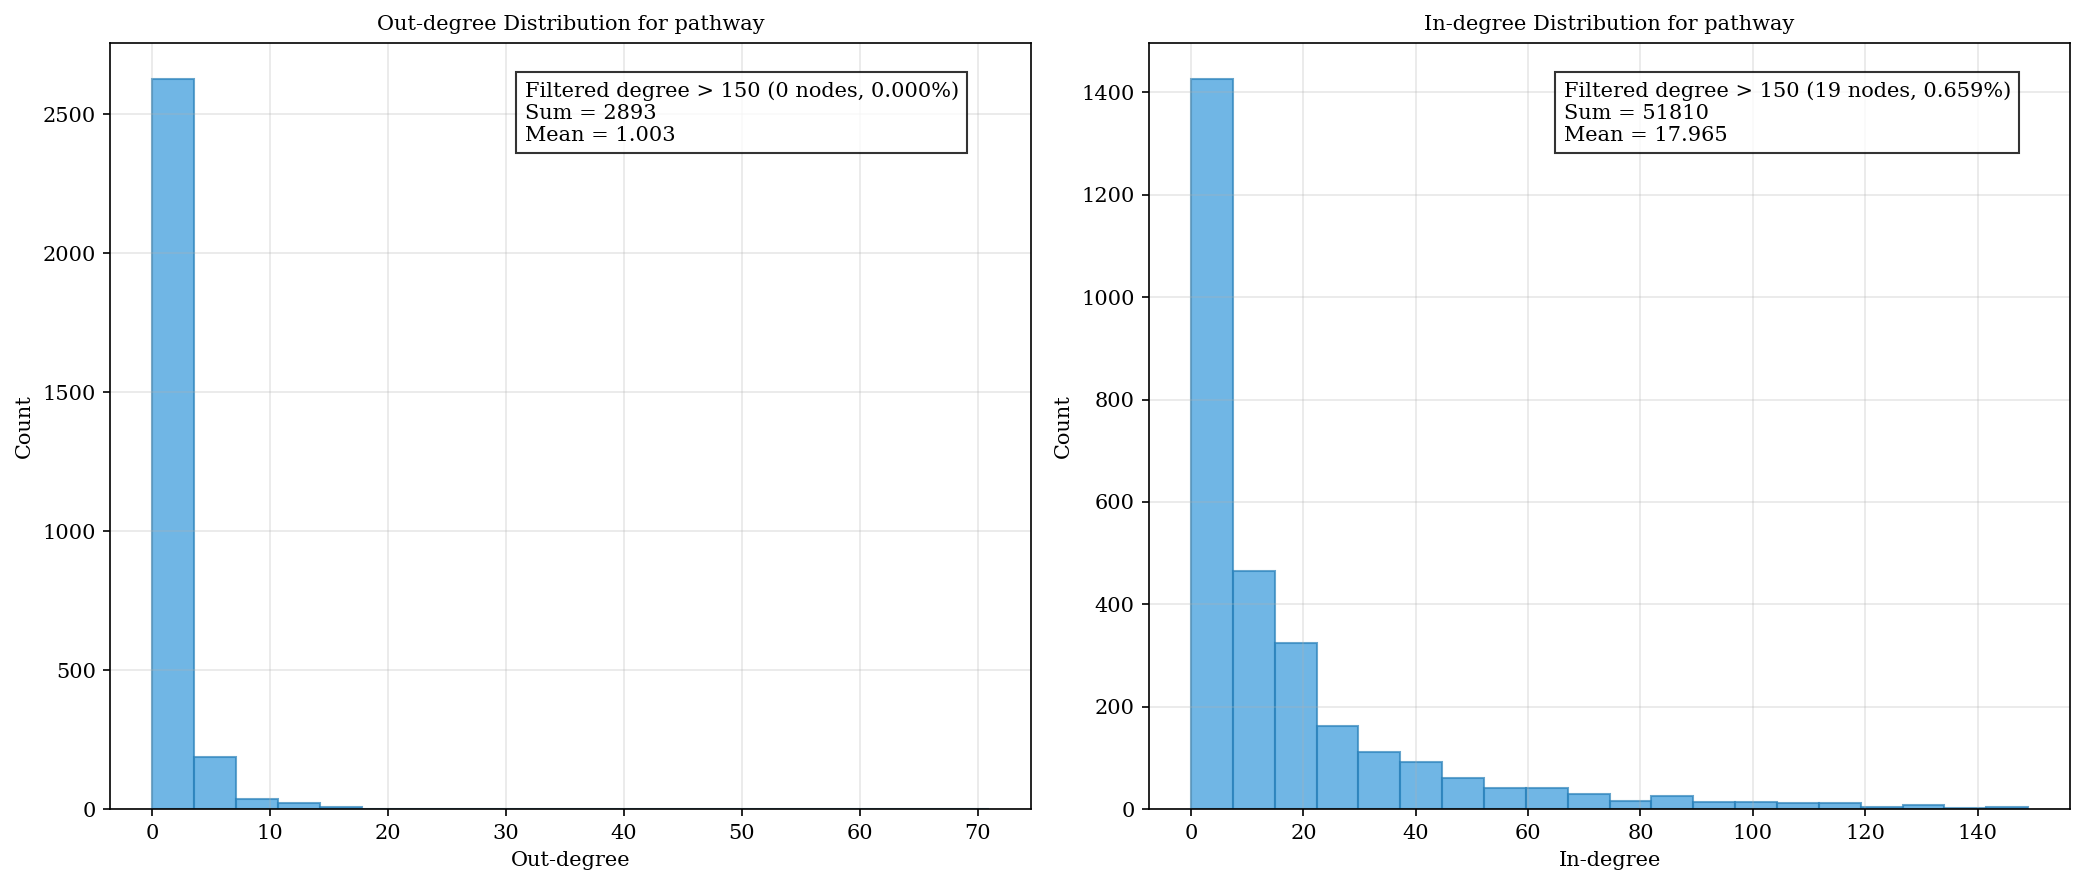

In [16]:
degree_distribution('pathway', threshold=150)

In [ ]:
def plot_node_relation_distribution(threshold: int = 500):
    plt.rcParams['figure.dpi'] = 150
    plt.rcParams['font.family'] = 'serif'


    head_relation = edges.groupby(['x_index', 'relation']).count().reset_index()['y_index']
    head_relation_threshold = head_relation <= threshold
    head_relation_filtered = head_relation[head_relation_threshold]

    tail_relation = edges.groupby(['y_index', 'relation']).count().reset_index()['x_index']
    tail_relation_threshold = tail_relation <= threshold
    tail_relation_filtered = tail_relation[tail_relation_threshold]

    head_relation_filtered_count = (~head_relation_threshold).sum()
    head_filtered_percent = (head_relation_filtered_count / len(head_relation)) * 100

    tail_relation_filtered_count = (~tail_relation_threshold).sum()
    tail_filtered_percent = (tail_relation_filtered_count / len(tail_relation)) * 100

    plt.figure(figsize=(14, 6))

    plt.subplot(121)
    plt.hist(head_relation_filtered, bins=20, alpha=0.7, color='#3498db', edgecolor='#2980b9', linewidth=1)
    plt.grid(True, alpha=0.3)
    plt.title('Number Distribution of Tail Entity for Each Relation Head Entity Pair', fontsize=10)
    plt.xlabel('Number')
    plt.ylabel('Count')
    plt.text(0.35, 0.95, 
        f'Total = {len(head_relation)}\n'
        f'Filtered number > {threshold} ({head_relation_filtered_count} pair, {head_filtered_percent:.3f}%)\n'
        f'Mean = {head_relation.mean():.3f}\n'
        f'Max = {head_relation.max()}\n'
        f'Min = {head_relation.min()}\n'
        f'Middle = {head_relation.median():.3f}', 
        transform=plt.gca().transAxes, 
        bbox=dict(facecolor='white', alpha=0.8),
        verticalalignment='top'
    )

    plt.subplot(122)
    plt.hist(tail_relation_filtered, bins=20, alpha=0.7, color='#3498db', edgecolor='#2980b9', linewidth=1)
    plt.grid(True, alpha=0.3)
    plt.title('Number Distribution of Head Entity for Each Relation Tail Entity Pair', fontsize=10)
    plt.xlabel('Number')
    plt.ylabel('Count')
    plt.text(0.35, 0.95, 
        f'Total = {len(tail_relation)}\n'
        f'Filtered number > {threshold} ({tail_relation_filtered_count} pair, {tail_filtered_percent:.3f}%)\n'
        f'Mean = {tail_relation.mean():.3f}\n'
        f'Max = {tail_relation.max()}\n'
        f'Min = {tail_relation.min()}\n'
        f'Middle = {tail_relation.median():.3f}', 
        transform=plt.gca().transAxes, 
        bbox=dict(facecolor='white', alpha=0.8),
        verticalalignment='top'
    )
    
    plt.show()

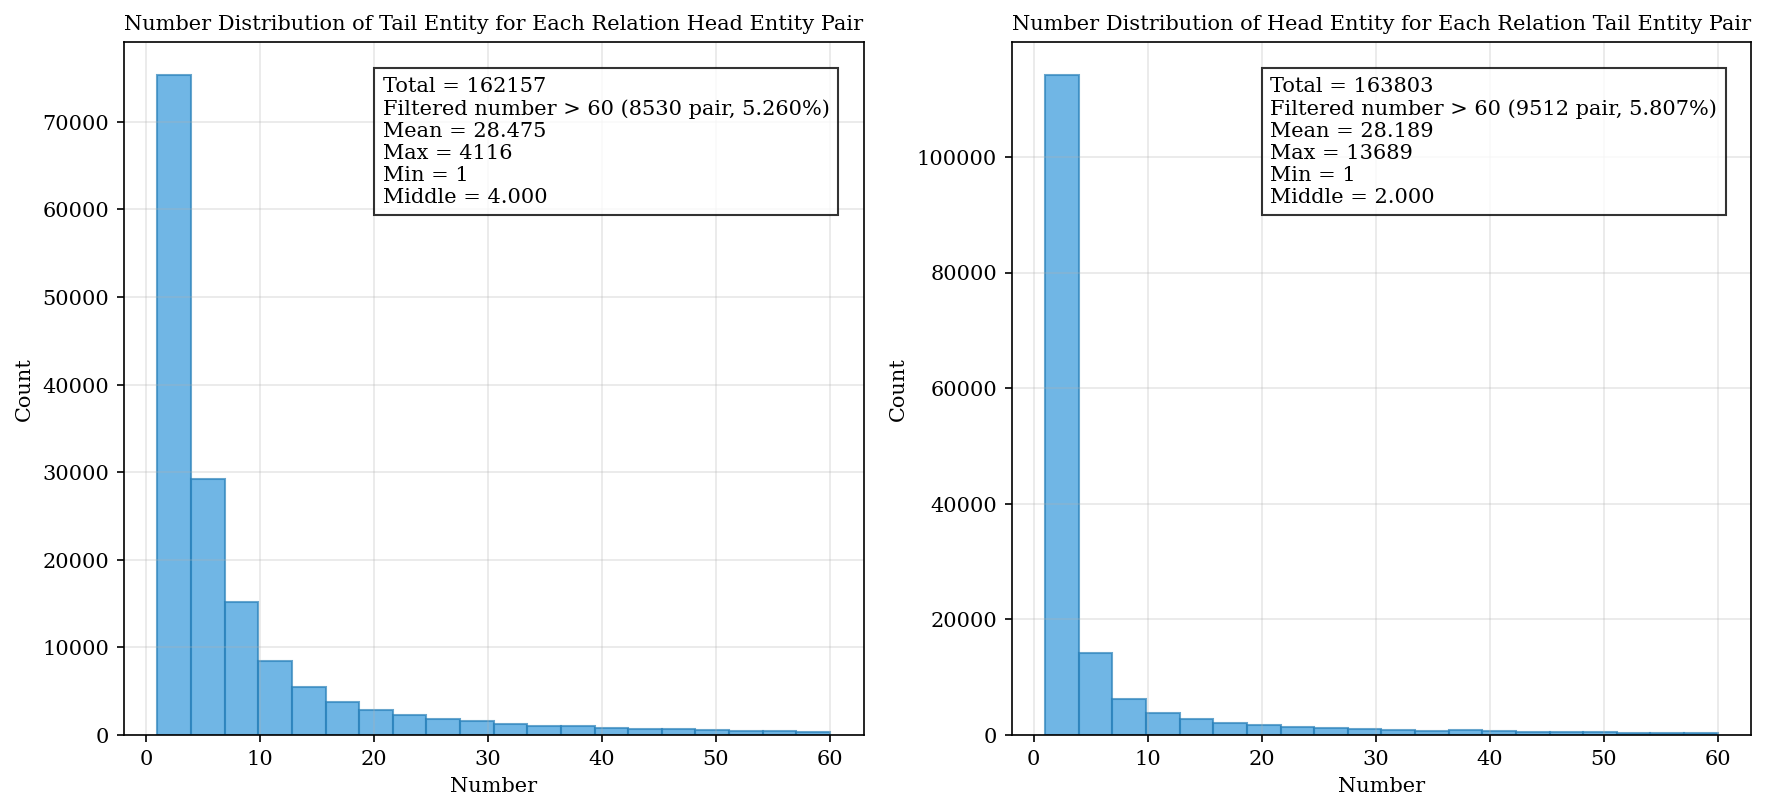

In [18]:
plot_node_relation_distribution(threshold=60)

疾病治疗相关

In [19]:
drug_disease = edges.query('relation == "indication" or relation == "off-label use"')
drug_disease.head()

,relation,display_relation,x_index,x_id,x_type,x_name,x_source,y_index,y_id,y_type,y_name,y_source
747010,indication,indication,17525,kg4rd:DB00435,drug,Nitric Oxide,DrugBank,72619,kg4rd:22430,disease,persistent fetal circulation syndrome,MONDO
747011,indication,indication,17525,kg4rd:DB00435,drug,Nitric Oxide,DrugBank,35500,kg4rd:9934,disease,alveolar capillary dysplasia with misalignment...,MONDO
747013,indication,indication,17525,kg4rd:DB00435,drug,Nitric Oxide,DrugBank,46059,kg4rd:5149,disease,pulmonary hypertension,MONDO
747014,indication,indication,22511,kg4rd:DB03843,drug,Formaldehyde,DrugBank,45494,kg4rd:5812,disease,influenza,MONDO
747015,indication,indication,19568,kg4rd:DB00536,drug,Guanidine,DrugBank,42687,kg4rd:18556,disease,Lambert-Eaton myasthenic syndrome,MONDO


In [33]:
def drug_disease_distribution(threshold: int = 50):

    all_disease = nodes.query('node_type == "disease"')[['node_index']].astype({'node_index': int}).astype({'node_index': str})

    # 尾实体必定为 disease 只能计算 in degree
    drug_disease_indication_in_degree = drug_disease.query('relation == "indication"').groupby('y_index').count()['relation'].reset_index().astype({'y_index': int}).astype({'y_index': str})
    df = pd.merge(drug_disease_indication_in_degree, all_disease, how="right", left_on='y_index', right_on='node_index')
    df = df[['relation', 'node_index']].fillna(0).astype({'relation': int})
    disease_indication_in_degree = df['relation']

    indication = disease_indication_in_degree <= threshold
    filtered_indication = disease_indication_in_degree[indication]
    filtered_indication_count = (~indication).sum()
    filtered_indication_percent = (filtered_indication_count / len(disease_indication_in_degree)) * 100

    drug_disease_olu_in_degree = drug_disease.query('relation == "off-label use"').groupby('y_index').count()['relation'].reset_index().astype({'y_index': int}).astype({'y_index': str})
    df = pd.merge(drug_disease_olu_in_degree, all_disease, how="right", left_on='y_index', right_on='node_index')
    df = df[['relation', 'node_index']].fillna(0).astype({'relation': int})
    disease_olu_in_degree = df['relation']

    olu = disease_olu_in_degree <= threshold
    filtered_olu = disease_olu_in_degree[olu]
    filtered_olu_count = (~olu).sum()
    filtered_olu_percent = (filtered_olu_count / len(disease_olu_in_degree)) * 100

    plt.rcParams['figure.dpi'] = 150
    plt.rcParams['font.family'] = 'serif'

    plt.figure(figsize=(14, 6))

    plt.subplot(121)
    plt.hist(filtered_indication, bins=10, alpha=0.7, color='#3498db', edgecolor='#2980b9', linewidth=1)
    plt.grid(True, alpha=0.3)
    plt.title(f'In-degree Distribution for disease (drug indication)', fontsize=10)
    plt.xlabel('In-degree')
    plt.ylabel('Count')
    plt.figtext(0.45, 0.95,
        f'Filtered degree > {threshold} ({filtered_indication_count} nodes, {filtered_indication_percent:.3f}%)\n'
        f'Sum = {disease_indication_in_degree.sum()}\n'
        f'Mean = {disease_indication_in_degree.mean():.3f}', 
        transform=plt.gca().transAxes, 
        bbox=dict(facecolor='white', alpha=0.8),
        verticalalignment='top'
    )

    plt.subplot(122)
    plt.hist(filtered_olu, bins=10, alpha=0.7, color='#3498db', edgecolor='#2980b9', linewidth=1)
    plt.grid(True, alpha=0.3)
    plt.title(f'In-degree Distribution for disease (drug off-label use)', fontsize=10)
    plt.xlabel('In-degree')
    plt.ylabel('Count')

    plt.figtext(0.45, 0.95,
        f'Filtered degree > {threshold} ({filtered_olu_count} nodes, {filtered_olu_percent:.3f}%)\n'
        f'Sum = {disease_olu_in_degree.sum()}\n'
        f'Mean = {disease_olu_in_degree.mean():.3f}', 
        transform=plt.gca().transAxes, 
        bbox=dict(facecolor='white', alpha=0.8),
        verticalalignment='top'
    )

    plt.tight_layout()
    plt.show()

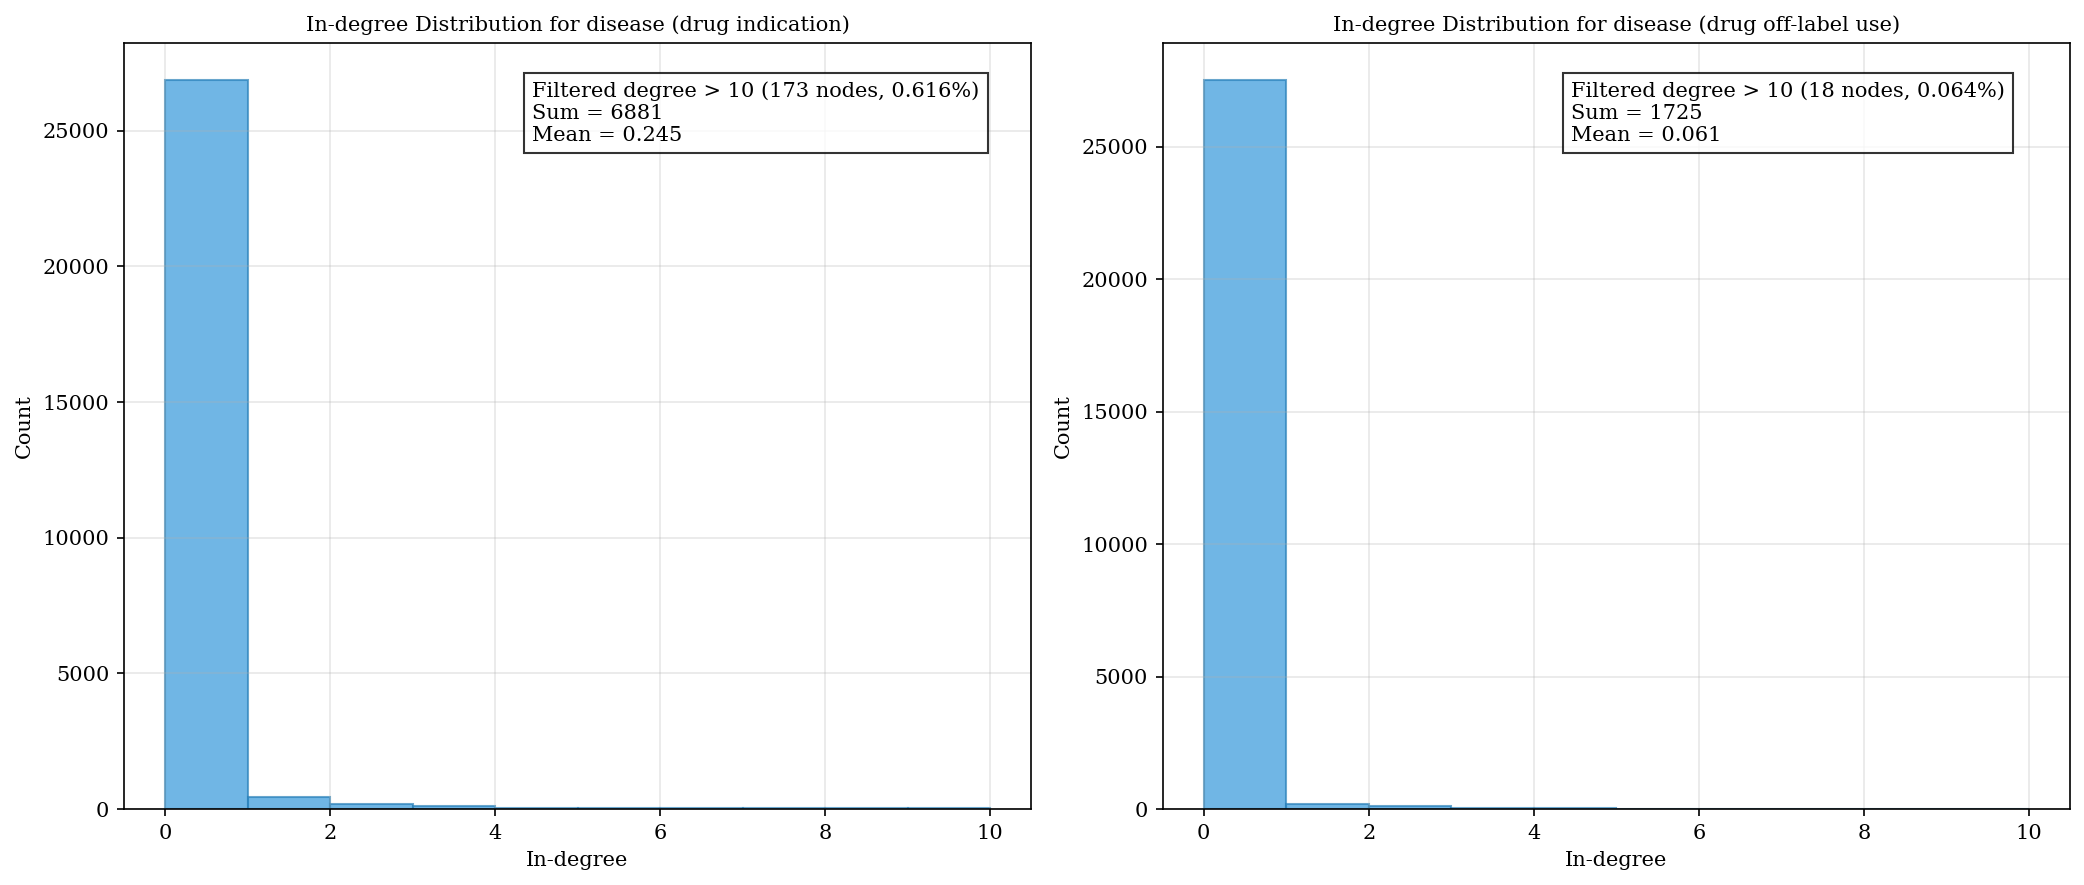

In [34]:
drug_disease_distribution(10)

罕见病治疗相关

In [26]:
ref = pd.read_csv('../../../data/data/mondo/mondo_references.csv').astype({'mondo_id':int}).astype({'mondo_id':str})
all_disease_nodes = nodes.query('node_type == "disease"').copy()
all_disease_nodes['node_id'] = all_disease_nodes['node_id'].apply(lambda x: str(x.lstrip('kg4rd:')))    
orphanets = pd.merge(all_disease_nodes, ref,'left', left_on='node_id', right_on='mondo_id')[[
    'mondo_id', 'ontology', 'ontology_id', 'node_name', 'node_index'
]].query('ontology == "Orphanet"')
orphanets.shape[0]

9162

In [ ]:

def drug_orphanet_disease_distribution(threshold: int = 50):

    all_rare_disease = orphanets[['node_index']].astype({'node_index': int}).astype({'node_index': str})

    drug_disease_indication_in_degree = drug_disease.query('relation == "indication"').groupby('y_index').count()['relation'].reset_index().astype({'y_index': int}).astype({'y_index': str})
    df = pd.merge(drug_disease_indication_in_degree, all_rare_disease, how="right", left_on='y_index', right_on='node_index')
    df = df[['relation', 'node_index']].fillna(0).astype({'relation': int})
    disease_indication_in_degree = df['relation']

    indication = disease_indication_in_degree <= threshold
    filtered_indication = disease_indication_in_degree[indication]
    filtered_indication_count = (~indication).sum()
    filtered_indication_percent = (filtered_indication_count / len(disease_indication_in_degree)) * 100

    drug_disease_olu_in_degree = drug_disease.query('relation == "off-label use"').groupby('y_index').count()['relation'].reset_index().astype({'y_index': int}).astype({'y_index': str})
    df = pd.merge(drug_disease_olu_in_degree, all_rare_disease, how="right", left_on='y_index', right_on='node_index')
    df = df[['relation', 'node_index']].fillna(0).astype({'relation': int})
    disease_olu_in_degree = df['relation']

    olu = disease_olu_in_degree <= threshold
    filtered_olu = disease_olu_in_degree[olu]
    filtered_olu_count = (~olu).sum()
    filtered_olu_percent = (filtered_olu_count / len(disease_olu_in_degree)) * 100

    plt.rcParams['figure.dpi'] = 150
    plt.rcParams['font.family'] = 'serif'

    plt.figure(figsize=(14, 6))

    plt.subplot(121)
    plt.hist(filtered_indication, bins=10, alpha=0.7, color='#3498db', edgecolor='#2980b9', linewidth=1)
    plt.grid(True, alpha=0.3)
    plt.title(f'In-degree Distribution for rare disease (drug indication)', fontsize=10)
    plt.xlabel('In-degree')
    plt.ylabel('Count')
    plt.figtext(0.5, 0.95,
        f'Filtered degree > {threshold} ({filtered_indication_count} nodes, {filtered_indication_percent:.3f}%)\n'
        f'Sum = {disease_indication_in_degree.sum()}\n'
        f'Mean = {disease_indication_in_degree.mean():.3f}', 
        transform=plt.gca().transAxes, 
        bbox=dict(facecolor='white', alpha=0.8),
        verticalalignment='top'
    )

    plt.subplot(122)
    plt.hist(filtered_olu, bins=10, alpha=0.7, color='#3498db', edgecolor='#2980b9', linewidth=1)
    plt.grid(True, alpha=0.3)
    plt.title(f'In-degree Distribution for rare disease (drug off-label use)', fontsize=10)
    plt.xlabel('In-degree')
    plt.ylabel('Count')

    plt.figtext(0.5, 0.95,
        f'Filtered degree > {threshold} ({filtered_olu_count} nodes, {filtered_olu_percent:.3f}%)\n'
        f'Sum = {disease_olu_in_degree.sum()}\n'
        f'Mean = {disease_olu_in_degree.mean():.3f}', 
        transform=plt.gca().transAxes, 
        bbox=dict(facecolor='white', alpha=0.8),
        verticalalignment='top'
    )

    plt.tight_layout()
    plt.show()

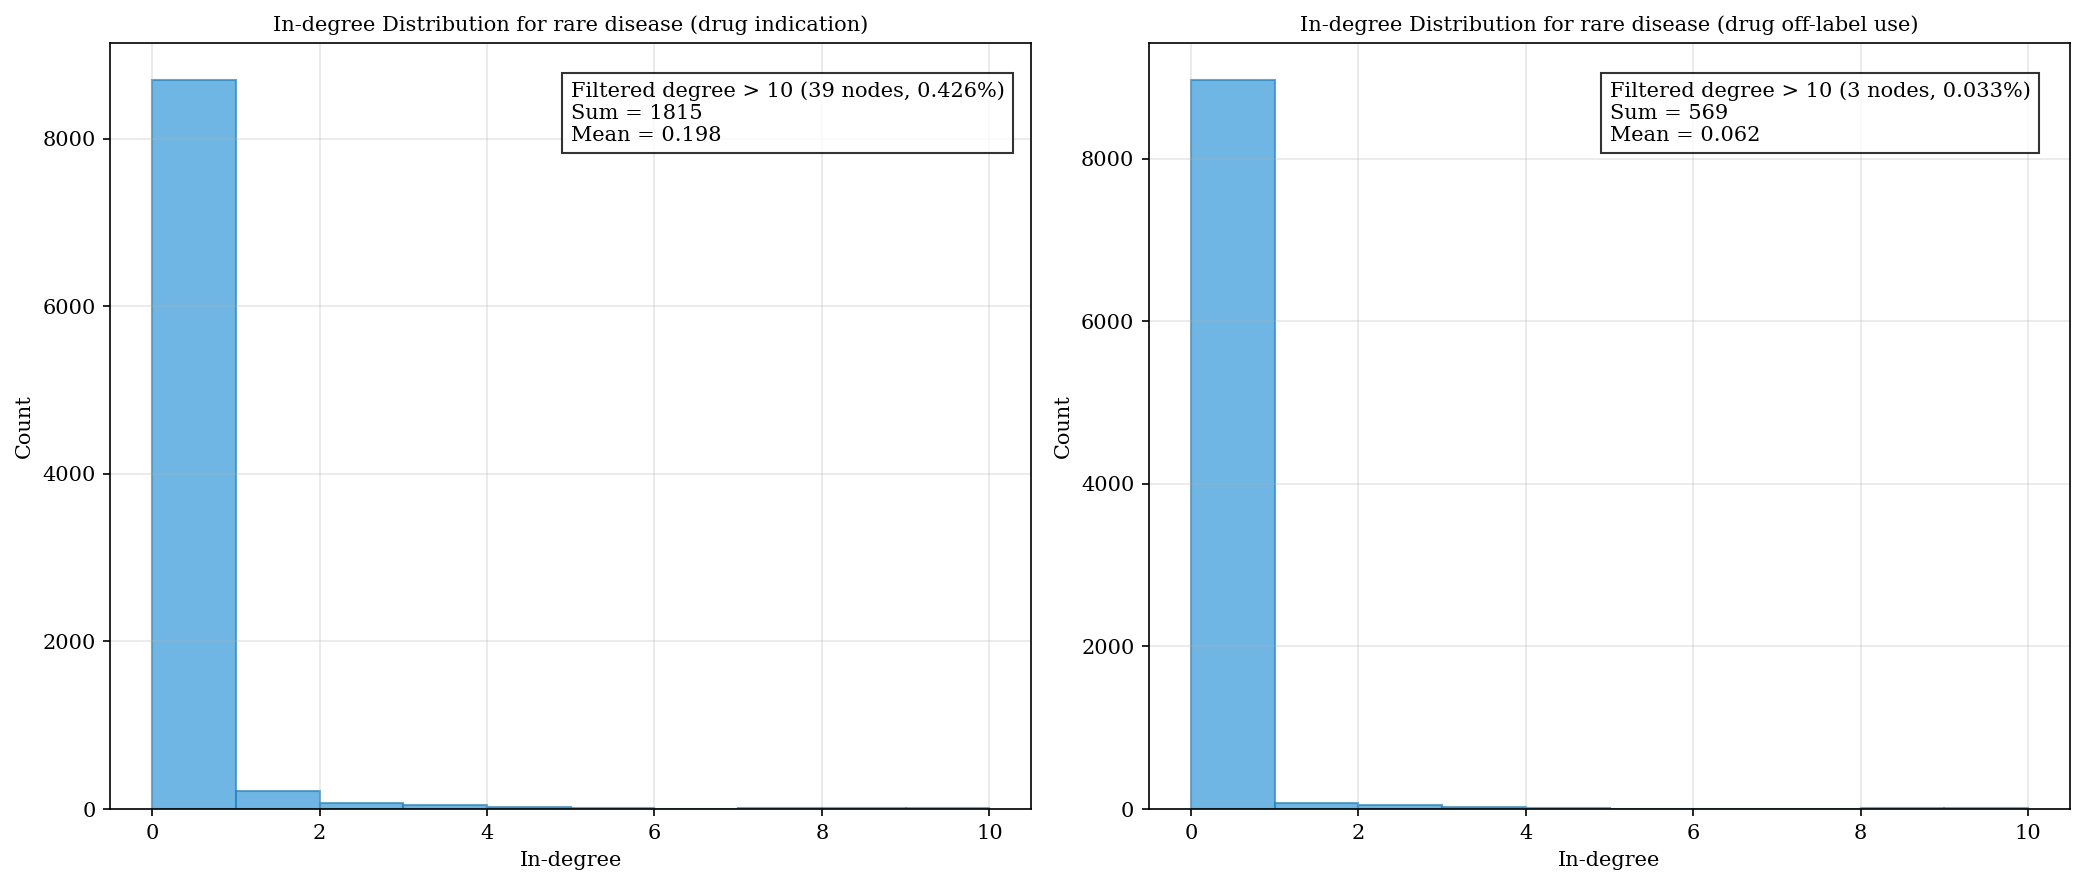

In [32]:
drug_orphanet_disease_distribution(threshold=10)